# Selective oversight: shopping-domain results analysis

This notebook produces tables and figures for DeepPlanning shopping-domain result sessions.

**Data sources**
- `outputs/deepplanning/experiments/system-*`: primary per-system result sessions
- `outputs/deepplanning/experiments/shopping-*`: legacy fallback result sessions when no `system-*` sessions are present
- `outputs/deepplanning/langfuse-results-usage.csv`: Langfuse token usage exported by this notebook via `scripts.export_langfuse_results_usage`

**Configuration**
- `RESULT_DIR_PREFIXES` selects experiment directories to analyze; default is `('system-',)`.
- `FALLBACK_RESULT_DIR_PREFIXES` keeps existing `shopping-*` outputs usable until system-named runs are present.
- `IGNORE_RESULT_PREFIXES` excludes prefixes such as `system-b`.
- `LANGFUSE_REFRESH_MODE` controls whether the notebook fetches fresh Langfuse usage: `missing`, `always`, or `never`.

**Conventions**
- Cost is reported in tokens primarily, dollars secondarily, with both as-billed and uncached-input dollar figures shown side by side.
- Case Accuracy = strict 0/1 (matched all required products, no extras).


In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pixi.toml').exists():
            return candidate
    raise RuntimeError('Could not find repo root containing pixi.toml')


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
for import_path in (REPO_ROOT, NOTEBOOK_DIR):
    import_path_s = str(import_path)
    if import_path_s not in sys.path:
        sys.path.insert(0, import_path_s)

import analysis_lib as al
from deepplanning.config import load_dotenv
from scripts import export_langfuse_results_usage as lf_export

OUTPUTS_ROOT = REPO_ROOT / 'outputs' / 'deepplanning'
EXPERIMENTS_ROOT = OUTPUTS_ROOT / 'experiments'
LANGFUSE = OUTPUTS_ROOT / 'langfuse-results-usage.csv'

# Primary selection is system-*; shopping-* is only used when no system-* outputs exist.
RESULT_DIR_PREFIXES = ('system-',)
FALLBACK_RESULT_DIR_PREFIXES = ('shopping-',)
IGNORE_RESULT_PREFIXES = ('system-b', 'shopping-b')
INCLUDE_SYSTEM_B = False

# `missing` fetches when LANGFUSE lacks any discovered session. Use `always` to force
# refresh, or `never` to use the existing CSV even when coverage is incomplete.
LANGFUSE_REFRESH_MODE = 'missing'  # one of: 'missing', 'always', 'never'
CONTINUE_ON_LANGFUSE_ERROR = False
LANGFUSE_LIMIT = 1000
LANGFUSE_TIMEOUT = 30.0

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 160,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

session_roots = al.discover_output_sessions(
    EXPERIMENTS_ROOT,
    include_prefixes=RESULT_DIR_PREFIXES,
    fallback_include_prefixes=FALLBACK_RESULT_DIR_PREFIXES,
    ignore_prefixes=IGNORE_RESULT_PREFIXES,
    include_system_b=INCLUDE_SYSTEM_B,
)
if not session_roots:
    raise RuntimeError(
        f'No result sessions found under {EXPERIMENTS_ROOT} for prefixes '
        f'{RESULT_DIR_PREFIXES} with fallback {FALLBACK_RESULT_DIR_PREFIXES}.'
    )

session_table = al.describe_sessions(session_roots)
expected_langfuse_sessions = set(session_table['timestamp'].astype(str))


def missing_langfuse_sessions(csv_path: Path, expected_sessions: set[str]) -> list[str]:
    if not csv_path.exists():
        return sorted(expected_sessions)
    frame = pd.read_csv(csv_path)
    if 'langfuse_session_id' not in frame.columns:
        return sorted(expected_sessions)
    present = set(frame['langfuse_session_id'].astype(str))
    return sorted(expected_sessions - present)


def refresh_langfuse_usage() -> pd.DataFrame:
    load_dotenv()
    public_key = os.getenv('LANGFUSE_PUBLIC_KEY', '')
    secret_key = os.getenv('LANGFUSE_SECRET_KEY', '')
    if not public_key or not secret_key:
        raise RuntimeError(
            'Langfuse refresh requested but LANGFUSE_PUBLIC_KEY and '
            'LANGFUSE_SECRET_KEY are not set in the environment or root .env.'
        )
    usage_fetcher = lf_export.make_langfuse_fetcher(
        host=os.getenv('LANGFUSE_HOST', lf_export.DEFAULT_LANGFUSE_HOST),
        public_key=public_key,
        secret_key=secret_key,
        limit=LANGFUSE_LIMIT,
        timeout=LANGFUSE_TIMEOUT,
    )
    rows = lf_export.build_report_rows(
        session_roots,
        usage_fetcher=usage_fetcher,
        continue_on_error=CONTINUE_ON_LANGFUSE_ERROR,
    )
    lf_export.write_report(rows, LANGFUSE)
    return pd.DataFrame(rows)

missing_lf = missing_langfuse_sessions(LANGFUSE, expected_langfuse_sessions)
refresh_mode = LANGFUSE_REFRESH_MODE.lower()
if refresh_mode not in {'missing', 'always', 'never'}:
    raise ValueError("LANGFUSE_REFRESH_MODE must be 'missing', 'always', or 'never'")
if refresh_mode == 'always' or (refresh_mode == 'missing' and missing_lf):
    print(f'Refreshing Langfuse usage for {len(session_roots)} discovered sessions...')
    refresh_langfuse_usage()
elif missing_lf:
    print(
        f'[warn] Langfuse CSV is missing {len(missing_lf)} discovered sessions. '
        "Set LANGFUSE_REFRESH_MODE = 'missing' or 'always' to fetch them."
    )

per_case = al.load_per_case(session_roots)
agg = al.load_aggregated(session_roots)
lf = al.load_langfuse(LANGFUSE)

loaded_systems = set(per_case['system'].dropna().unique())
if not lf.empty:
    loaded_systems.update(lf['system'].dropna().unique())
SYSTEM_ORDER = al.set_system_order(loaded_systems)

# Consistent colors per system across every plot; generated colors cover new variants.
SYSTEM_COLORS = {
    'A': '#7f7f7f',
    'B': '#ff7f0e',
    'C1': '#2ca02c',
    'C2': '#1f77b4',
    'C2-deepseek-pro': '#000000',
    'C2-nt': '#aec7e8',
    'C2-noretry': '#9ecae1',
    'C2-deepseek': '#9467bd',
    'D': '#d62728',
}
palette = sns.color_palette('tab20', n_colors=max(len(SYSTEM_ORDER), 1)).as_hex()
for system, color in zip(SYSTEM_ORDER, palette):
    SYSTEM_COLORS.setdefault(system, color)

print(f'Discovered {len(session_roots)} result sessions under {EXPERIMENTS_ROOT}')
print(f'Loaded {len(per_case)} per-case rows, {len(agg)} aggregated-run rows')
print(f'Systems present: {SYSTEM_ORDER}')
display(session_table[['system', 'experiment_name', 'timestamp']])


Refreshing Langfuse usage for 10 discovered sessions...
Discovered 10 result sessions under /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/experiments
Loaded 3840 per-case rows, 32 aggregated-run rows
Systems present: ['A', 'C2', 'C2-nt', 'C2-noretry', 'C2-deepseek', 'C2-deepseek-nt', 'C2-deepseek-pro', 'D']


,system,experiment_name,timestamp
0,A,shopping-a,2026-04-29_21-02-41
1,C2,shopping-c2,2026-04-30_09-18-02
2,C2-deepseek,shopping-c2-deepseek,2026-05-01_18-54-47
3,C2-deepseek,shopping-c2-deepseek,2026-05-10_18-11-57
4,C2-deepseek-nt,shopping-c2-deepseek-nt,2026-05-10_18-08-50
5,C2-deepseek-pro,shopping-c2-deepseek-pro,2026-05-13_01-07-58
6,C2-noretry,shopping-c2-noretry,2026-04-29_21-07-58
7,C2-nt,shopping-c2-nt,2026-04-30_13-35-38
8,D,shopping-d,2026-05-01_18-31-44
9,D,shopping-d,2026-05-10_18-12-52


## 1. Per-system accuracy summary

In [4]:
ss = al.system_summary(per_case)
display_cols = ['system','runs','case_acc_mean','case_acc_std',
                'L1_mean','L2_mean','L3_mean','match_rate_mean']
fmt = {'case_acc_mean': '{:.4f}', 'case_acc_std': '{:.4f}',
       'L1_mean': '{:.3f}', 'L2_mean': '{:.3f}', 'L3_mean': '{:.3f}',
       'match_rate_mean': '{:.4f}'}
ss[display_cols].style.format(fmt)


,system,runs,case_acc_mean,case_acc_std,L1_mean,L2_mean,L3_mean,match_rate_mean
0,A,4,0.3542,0.0048,0.425,0.305,0.300,0.7207
1,C2,4,0.3875,0.0250,0.475,0.320,0.337,0.7541
2,C2-nt,4,0.3979,0.0105,0.450,0.365,0.350,0.7486
3,C2-noretry,4,0.3708,0.0144,0.450,0.310,0.325,0.7193
4,C2-deepseek,4,0.5667,0.0226,0.620,0.520,0.550,0.8379
5,C2-deepseek-nt,4,0.5708,0.0210,0.640,0.505,0.562,0.8480
6,C2-deepseek-pro,4,0.5646,0.0322,0.625,0.505,0.562,0.8503
7,D,4,0.5188,0.0322,0.600,0.435,0.525,0.8388


### Reading the table
- Case Accuracy is averaged across runs; std is the per-run stdev.
- L1/L2/L3 = case accuracy at constraint complexity levels 1, 2, 3 (50/50/20 cases).
- D and C2-deepseek have only 2 runs (cost saving — see protocol).


In [5]:
# Per-run breakdown — useful to eyeball variance
per_run = al.per_run_overall(per_case).sort_values(['system','run'])
per_run.style.format({'case_accuracy': '{:.4f}', 'mean_score': '{:.4f}',
                      'match_rate': '{:.4f}'})


,system,run,case_accuracy,mean_score,successes,total,match_rate,expected_total
0,A,0,0.3500,0.7218,42,120,0.7179,546
1,A,1,0.3500,0.7166,42,120,0.7143,546
2,A,2,0.3583,0.7236,43,120,0.7271,546
3,A,3,0.3583,0.7207,43,120,0.7234,546
4,C2,0,0.3583,0.7412,43,120,0.7436,546
5,C2,1,0.4083,0.7508,49,120,0.7564,546
6,C2,2,0.3750,0.7567,45,120,0.7601,546
7,C2,3,0.4083,0.7591,49,120,0.7564,546
8,C2-deepseek,0,0.5500,0.8285,66,120,0.8242,546
9,C2-deepseek,1,0.6000,0.8619,72,120,0.8590,546


## 2. Token volume and cache hit rate per system

In [6]:
tok = al.system_token_summary(lf)
tok_disp = tok[['system','runs','per_run_input_uncached','per_run_input_cached',
                'per_run_output','per_run_total','cache_hit_rate']].copy()
for c in ['per_run_input_uncached','per_run_input_cached','per_run_output','per_run_total']:
    tok_disp[c] = tok_disp[c] / 1e6   # show in millions
tok_disp = tok_disp.rename(columns={
    'per_run_input_uncached': 'in_uncached_M',
    'per_run_input_cached':   'in_cached_M',
    'per_run_output':         'out_M',
    'per_run_total':          'total_M',
})
tok_disp.style.format({'in_uncached_M':'{:.1f}','in_cached_M':'{:.1f}',
                       'out_M':'{:.2f}','total_M':'{:.1f}',
                       'cache_hit_rate':'{:.1%}'})


,system,runs,in_uncached_M,in_cached_M,out_M,total_M,cache_hit_rate
0,A,4,126.3,0.0,1.00,127.3,0.0%
1,C2,4,182.6,1.8,1.81,187.2,1.0%
2,C2-nt,4,131.5,1.9,1.77,136.1,1.4%
3,C2-noretry,4,102.3,1.2,1.27,105.5,1.1%
4,C2-deepseek,4,7.7,84.3,1.03,95.1,91.6%
5,C2-deepseek-nt,4,7.4,82.1,0.87,92.3,91.8%
6,C2-deepseek-pro,4,7.8,87.9,0.89,99.4,91.9%
7,D,4,3.5,54.4,0.44,59.1,94.0%


### Two notes on the cache numbers

1. **Qwen via DashScope reports 0% cached** in our Langfuse data. This may be a
   provider/integration limitation rather than absence of physical caching.
   For the cost story we treat it as 0% (which is the as-billed reality).
2. **C2-deepseek's `combined` row** sums executor + overseer because Langfuse
   rolls up by model name and both calls hit `deepseek-v4-flash`. We can't
   split executor vs overseer cache hit for that system.


## 3. Dollar costs

In [7]:
co = al.cost_dollars(lf)
co.style.format({'total_usd_as_billed':'${:.2f}',
                 'total_usd_uncached':'${:.2f}',
                 'per_run_usd_as_billed':'${:.2f}',
                 'per_run_usd_uncached':'${:.2f}'})


,system,runs,total_usd_as_billed,total_usd_uncached,per_run_usd_as_billed,per_run_usd_uncached
0,A,4,$51.13,$51.13,$12.78,$12.78
1,C2,4,$74.90,$75.90,$18.72,$18.97
2,C2-nt,4,$54.49,$55.51,$13.62,$13.88
3,C2-noretry,4,$42.26,$42.90,$10.56,$10.72
4,C2-deepseek,4,$6.42,$52.67,$1.60,$13.17
5,C2-deepseek-nt,4,$6.03,$51.08,$1.51,$12.77
6,C2-deepseek-pro,4,$6.32,$54.57,$1.58,$13.64
7,D,4,$3.04,$32.87,$0.76,$8.22


### Pricing assumptions used above

Edit `analysis_lib.py` to change. Current values (USD per 1M tokens):

- DeepSeek v4-flash: input uncached **$0.27**, input cached **$0.07**, output **$1.10**
- Qwen3.5-9B (DashScope): input **$0.40**, output **$1.20** (no cached tier in our data)

The "uncached" column re-prices all input tokens at the uncached rate — useful
for stripping out the cache subsidy and comparing token *volume* dressed in dollars.


## 4. Headline plot: accuracy vs cost (Pareto)

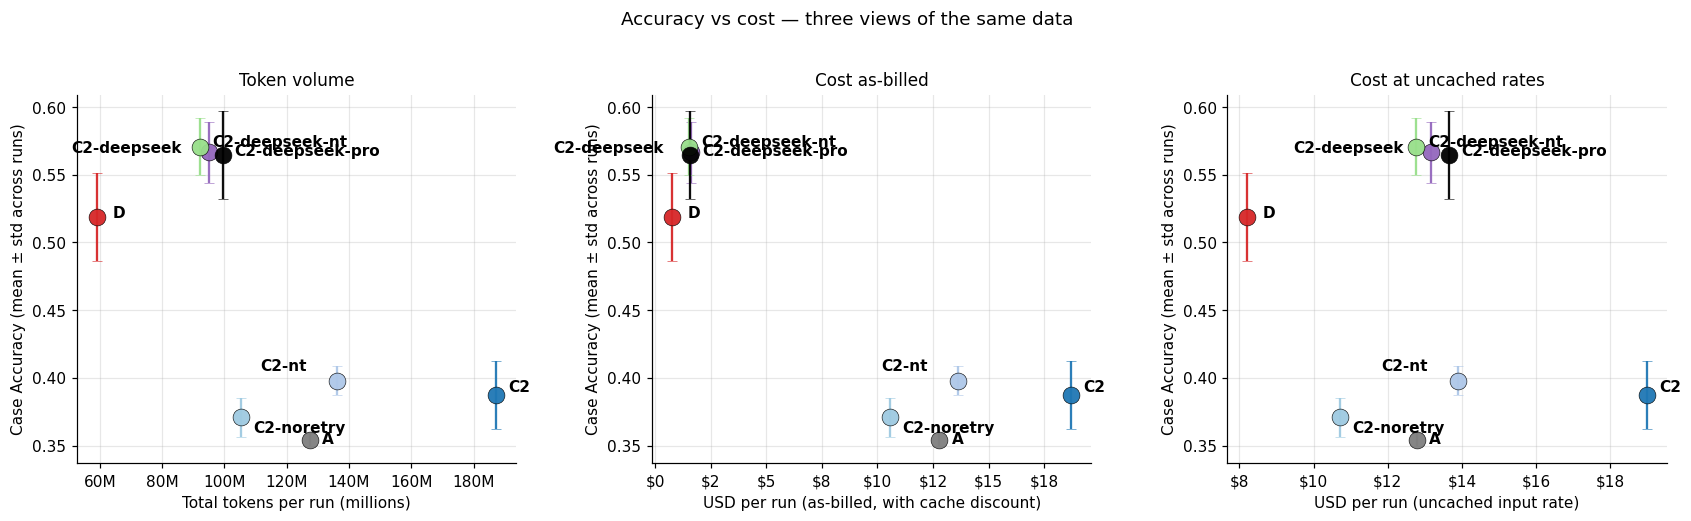

In [8]:
def pareto_plot(ax, x_col, x_label, x_unit_fmt):
    co_local = al.cost_dollars(lf).set_index('system')
    tok_local = al.system_token_summary(lf).set_index('system')
    ss_local = al.system_summary(per_case).set_index('system')
    for s in SYSTEM_ORDER:
        if s not in ss_local.index or s not in tok_local.index or s not in co_local.index:
            continue
        if x_col == 'per_run_total':
            x = tok_local.loc[s, 'per_run_total'] / 1e6
        elif x_col == 'per_run_usd_as_billed':
            x = co_local.loc[s, 'per_run_usd_as_billed']
        elif x_col == 'per_run_usd_uncached':
            x = co_local.loc[s, 'per_run_usd_uncached']
        y = ss_local.loc[s, 'case_acc_mean']
        yerr = ss_local.loc[s, 'case_acc_std']
        ax.errorbar(x, y, yerr=yerr, fmt='o', markersize=11,
                    color=SYSTEM_COLORS[s], capsize=3, alpha=0.95,
                    markeredgecolor='black', markeredgewidth=0.4)
        offsets = {'A': (8, -2), 'C2': (8, 2), 'C2-nt': (-50, 7),
                   'C2-noretry': (8, -10), 'C2-deepseek': (-90, 0), 'D': (10, 0)}
        dx, dy = offsets.get(s, (8, 0))
        ax.annotate(s, (x, y), xytext=(dx, dy), textcoords='offset points',
                    fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Case Accuracy (mean ± std across runs)')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(x_unit_fmt))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
pareto_plot(axes[0], 'per_run_total',
            'Total tokens per run (millions)',
            lambda v, _: f'{v:.0f}M')
pareto_plot(axes[1], 'per_run_usd_as_billed',
            'USD per run (as-billed, with cache discount)',
            lambda v, _: f'${v:.0f}')
pareto_plot(axes[2], 'per_run_usd_uncached',
            'USD per run (uncached input rate)',
            lambda v, _: f'${v:.0f}')
axes[0].set_title('Token volume')
axes[1].set_title('Cost as-billed')
axes[2].set_title('Cost at uncached rates')
fig.suptitle('Accuracy vs cost — three views of the same data', y=1.02)
plt.tight_layout()
plt.savefig('out_pareto.png', bbox_inches='tight')
plt.show()


### What the three panels show

- **Left (tokens)**: D is the cheapest at 60M tokens/run because of within-trajectory
  prefix caching that gets billed at the cached rate. C2-deepseek pays a token-volume
  premium (~58% more than D) for its +2.9pp accuracy gain.
- **Middle (USD as-billed)**: D and C2-deepseek look dramatically cheaper because
  DeepSeek's cached-input price is ~4× lower than uncached. The qwen executor in
  C2/C2-nt/C2-noretry/A pays full input rates everywhere.
- **Right (USD uncached)**: when we strip the cache subsidy, the gap shrinks but the
  ordering is unchanged. **The cache locality of monolithic / single-provider runs
  is a real architectural advantage**, but the underlying token-volume gap is also
  real.


## 5. Per-level case accuracy

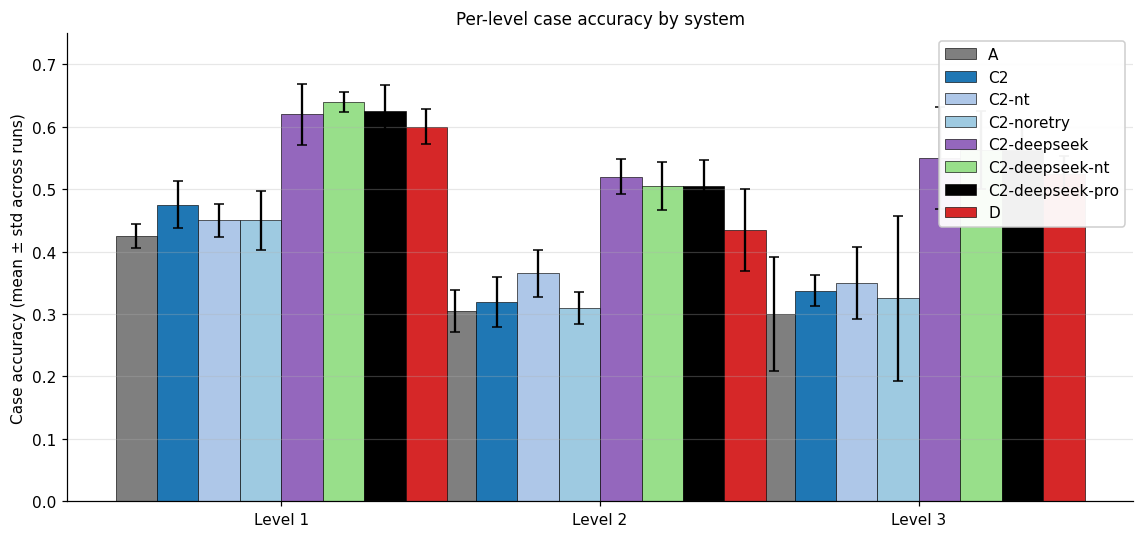

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5))
per_level = al.per_run_per_level(per_case)
agg_level = (per_level.groupby(['system','level'], as_index=False)
                       .agg(mean=('case_accuracy','mean'),
                            std=('case_accuracy','std')))

systems_present = [s for s in SYSTEM_ORDER if s in agg_level.system.unique()]
levels = [1, 2, 3]
x = np.arange(len(levels))
width = 0.13
for i, s in enumerate(systems_present):
    sub = agg_level[agg_level.system == s].sort_values('level')
    means = sub['mean'].values
    stds  = sub['std'].fillna(0).values
    pos = x + (i - (len(systems_present)-1)/2) * width
    ax.bar(pos, means, width, label=s, color=SYSTEM_COLORS[s],
           yerr=stds, capsize=3, edgecolor='black', linewidth=0.4)

ax.set_xticks(x); ax.set_xticklabels([f'Level {L}' for L in levels])
ax.set_ylabel('Case accuracy (mean ± std across runs)')
ax.set_title('Per-level case accuracy by system')
ax.legend(loc='upper right', framealpha=0.95)
ax.set_ylim(0, 0.75)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('out_per_level.png', bbox_inches='tight')
plt.show()


### Reading per-level results
- All systems degrade from L1 → L3 as constraint complexity rises.
- The C2-deepseek vs D gap is largest at L1 (+4pp) — strong executor + oversight
  helps most when individual constraints are clearer to verify.
- The qwen-executor systems (A, C2, C2-nt, C2-noretry) cluster tightly together
  at every level — model identity dominates ablation choices.


## 6. Token volume breakdown (executor vs overseer, cached vs uncached)

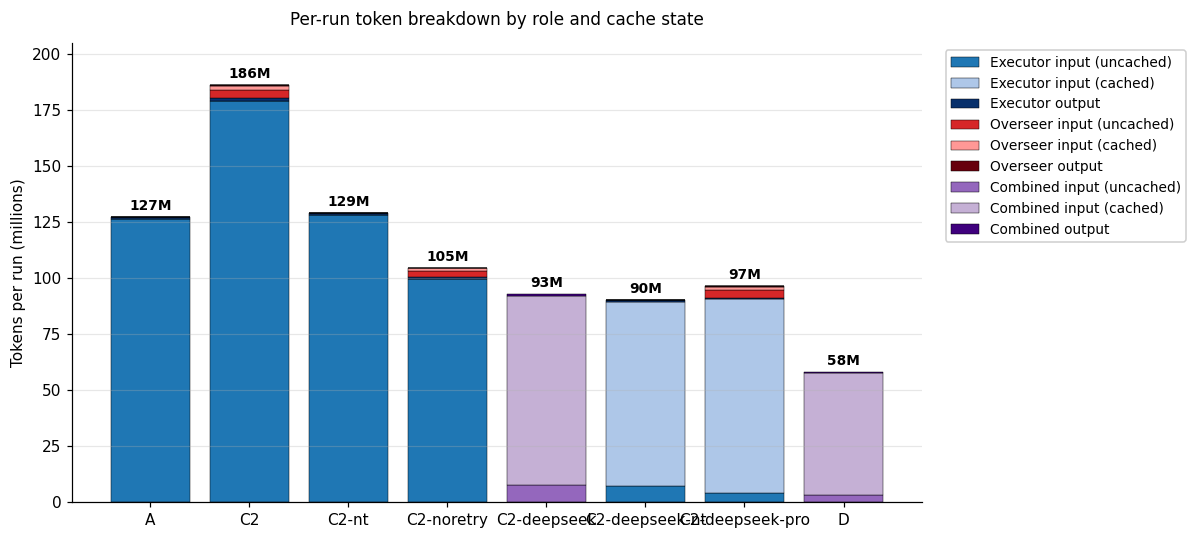

In [10]:
breakdown = (lf.assign(
                 per_run_in_unc=lf['per_run_input_uncached'],
                 per_run_in_cached=lf['per_run_input_cached'],
                 per_run_out=lf['per_run_output'],
             )
             .groupby(['system','role'], as_index=False)
             .agg(in_unc=('per_run_in_unc','sum'),
                  in_cached=('per_run_in_cached','sum'),
                  out=('per_run_out','sum')))

systems_present = [s for s in SYSTEM_ORDER if s in breakdown.system.unique()]
fig, ax = plt.subplots(figsize=(11, 5))
xs = np.arange(len(systems_present))
bottoms = np.zeros(len(systems_present))

# Stack: executor in_unc, executor in_cached, executor out, overseer in_unc, overseer in_cached, overseer out
stack_order = [
    ('executor', 'in_unc',     '#1f77b4', 'Executor input (uncached)'),
    ('executor', 'in_cached',  '#aec7e8', 'Executor input (cached)'),
    ('executor', 'out',        '#08306b', 'Executor output'),
    ('overseer', 'in_unc',     '#d62728', 'Overseer input (uncached)'),
    ('overseer', 'in_cached',  '#ff9896', 'Overseer input (cached)'),
    ('overseer', 'out',        '#67000d', 'Overseer output'),
    ('combined', 'in_unc',     '#9467bd', 'Combined input (uncached)'),
    ('combined', 'in_cached',  '#c5b0d5', 'Combined input (cached)'),
    ('combined', 'out',        '#3f007d', 'Combined output'),
]
for role, col, color, label in stack_order:
    vals = []
    for s in systems_present:
        sub = breakdown[(breakdown.system == s) & (breakdown.role == role)]
        v = sub[col].sum() / 1e6 if not sub.empty else 0.0
        vals.append(v)
    if all(v == 0 for v in vals):
        continue
    ax.bar(xs, vals, bottom=bottoms, label=label, color=color,
           edgecolor='black', linewidth=0.3)
    bottoms = bottoms + np.array(vals)

ax.set_xticks(xs); ax.set_xticklabels(systems_present)
ax.set_ylabel('Tokens per run (millions)')
ax.set_title('Per-run token breakdown by role and cache state', pad=12)
ax.set_ylim(0, max(bottoms) * 1.10)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.95, fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Annotate total on top of each bar
for i, total in enumerate(bottoms):
    ax.text(xs[i], total + 3, f'{total:.0f}M', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('out_token_breakdown.png', bbox_inches='tight')
plt.show()


### What this plot shows

- **A** is one bar of qwen executor input + a sliver of output (~127M total).
- **C2/C2-nt/C2-noretry** add a small overseer slice (the red on top), but the
  executor bar swells beyond A's height — **this is the trajectory inflation finding**.
- **D and C2-deepseek** have most of their input mass in the *cached* (light) band
  thanks to deepseek's prefix caching across the trajectory.
- **C2-deepseek's `combined` bar** (purple) shows that even when the same model
  serves executor and overseer, total per-run cost is ~58% higher than D.


## 7. Trajectory inflation: A vs C2 executor calls

In [11]:
exec_only = lf[lf.role.isin(['executor', 'combined'])].copy()
exec_only = exec_only[['system','model','runs','input_uncached','input_cached',
                       'output','per_run_total','cache_hit_rate']]
exec_only['per_run_total_M'] = exec_only['per_run_total'] / 1e6
exec_only.style.format({
    'input_uncached': '{:,.0f}',
    'input_cached':   '{:,.0f}',
    'output':         '{:,.0f}',
    'per_run_total':  '{:,.0f}',
    'per_run_total_M':'{:.1f}',
    'cache_hit_rate': '{:.1%}',
})


,system,model,runs,input_uncached,input_cached,output,per_run_total,cache_hit_rate,per_run_total_M
0,A,Qwen/Qwen3.5-9B,4,"505,304,095",0,"3,983,962","127,322,014",0.0%,127.3
1,C2,Qwen/Qwen3.5-9B,4,"715,843,466",0,"5,728,168","180,392,908",0.0%,180.4
3,C2-deepseek,deepseek-v4-flash,4,"30,834,825","337,118,208","4,130,689","95,119,999",91.6%,95.1
4,C2-deepseek-nt,deepseek-v4-flash,4,"29,513,785","328,370,816","3,487,969","92,265,124",91.8%,92.3
5,C2-deepseek-pro,deepseek-v4-flash,4,"17,098,910","345,586,176","2,543,068","92,379,922",95.3%,92.4
7,C2-noretry,Qwen/Qwen3.5-9B,4,"398,337,194",0,"4,159,806","100,624,250",0.0%,100.6
9,C2-nt,Qwen/Qwen3.5-9B,4,"512,157,511",0,"5,106,051","129,315,890",0.0%,129.3
11,D,deepseek-v4-flash,4,"13,811,961","217,400,960","1,769,523","59,078,156",94.0%,59.1


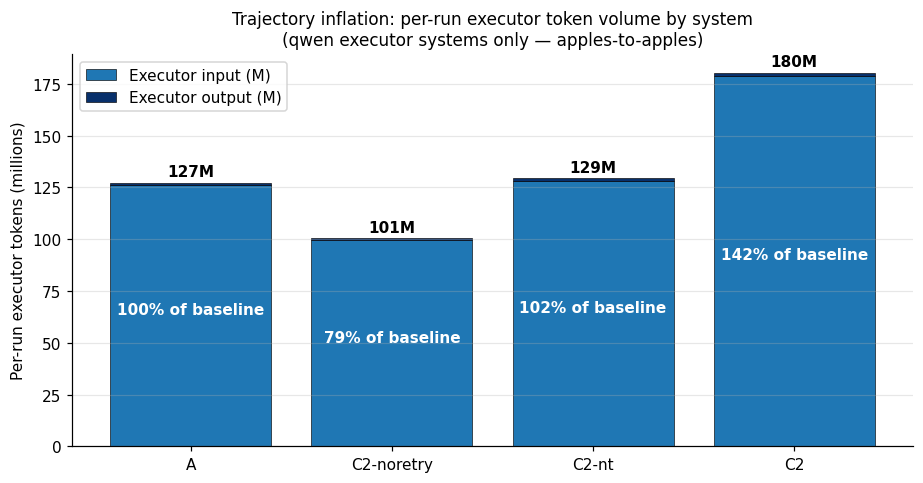

In [12]:
# Bar chart: executor-side per-run input tokens for qwen-executor systems.
qwen_systems = [s for s in ['A', 'C2-noretry', 'C2-nt', 'C2'] if s in set(lf.system)]
data = []
for s in qwen_systems:
    row = lf[(lf.system == s) & (lf.role == 'executor')]
    if not row.empty:
        data.append((s, row['per_run_input_uncached'].sum() / 1e6,
                        row['per_run_output'].sum() / 1e6))

if not data:
    print('No qwen executor systems with Langfuse usage are available for this plot.')
else:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    xs = np.arange(len(data))
    inputs = [d[1] for d in data]
    outputs = [d[2] for d in data]
    ax.bar(xs, inputs,  color='#1f77b4', edgecolor='black', linewidth=0.4, label='Executor input (M)')
    ax.bar(xs, outputs, bottom=inputs, color='#08306b', edgecolor='black', linewidth=0.4, label='Executor output (M)')
    ax.set_xticks(xs); ax.set_xticklabels([d[0] for d in data])
    ax.set_ylabel('Per-run executor tokens (millions)')
    ax.set_title('Trajectory inflation: per-run executor token volume by system\n(qwen executor systems only — apples-to-apples)')
    base_total = next((inp + outp for s, inp, outp in data if s == 'A'), data[0][1] + data[0][2])
    for i, (s, inp, outp) in enumerate(data):
        total = inp + outp
        ax.text(i, total + 3, f'{total:.0f}M', ha='center', fontweight='bold')
        pct_vs_base = total / base_total * 100 if base_total else np.nan
        ax.text(i, total / 2, f'{pct_vs_base:.0f}% of baseline', ha='center', color='white',
                fontsize=10, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('out_trajectory_inflation.png', bbox_inches='tight')
    plt.show()


### The trajectory-inflation finding

Going from `A → C2-noretry → C2-nt → C2`, the qwen executor's per-run input
tokens are 126M → 100M → 128M → 179M.

- **C2-noretry's executor uses *less* than A** — without retries, oversight stops
  trajectories early when it thinks the answer is final. So oversight by itself
  is mildly compressive.
- **C2-nt's executor matches A** — when the overseer doesn't think, it inserts
  fewer notices that re-trigger executor work.
- **Full C2's executor uses 42% more than A** — the combination of thinking-mode
  overseer notices + retries inflates trajectories substantially.

This is a **mechanism-level finding**: thinking-mode overseer feedback creates
extra executor work that retries then amplify. And it does **not** translate into
accuracy (C2 is statistically tied with C2-nt on case accuracy).


## 8. Cache hit rate by role and system

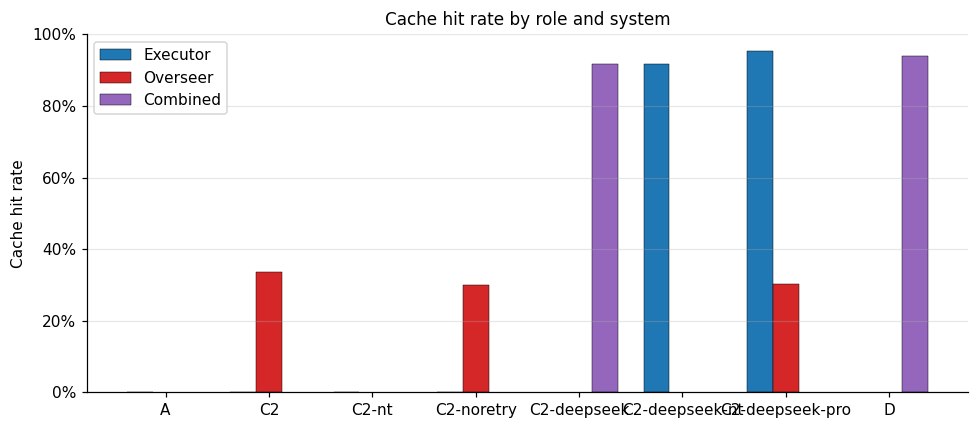

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_rows = []
for s in SYSTEM_ORDER:
    sub = lf[lf.system == s]
    for _, r in sub.iterrows():
        if (r['input_uncached'] + r['input_cached']) > 0:
            plot_rows.append({
                'system': s, 'role': r['role'],
                'cache_hit_rate': r['cache_hit_rate'],
                'model': r['model'],
            })
pdf = pd.DataFrame(plot_rows)

systems_present = [s for s in SYSTEM_ORDER if s in pdf.system.unique()]
roles_present = ['executor', 'overseer', 'combined']
xs = np.arange(len(systems_present))
width = 0.25
role_colors = {'executor': '#1f77b4', 'overseer': '#d62728', 'combined': '#9467bd'}

for i, role in enumerate(roles_present):
    vals = []
    for s in systems_present:
        sub = pdf[(pdf.system == s) & (pdf.role == role)]
        vals.append(sub['cache_hit_rate'].iloc[0] if not sub.empty else np.nan)
    pos = xs + (i - 1) * width
    ax.bar(pos, vals, width, label=role.capitalize(), color=role_colors[role],
           edgecolor='black', linewidth=0.3)

ax.set_xticks(xs); ax.set_xticklabels(systems_present)
ax.set_ylabel('Cache hit rate')
ax.set_title('Cache hit rate by role and system')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
plt.tight_layout()
plt.savefig('out_cache_hit.png', bbox_inches='tight')
plt.show()


### Cache hit rate by role

- **D's executor**: ~94% cached (single-agent, growing trajectory = perfect cache locality).
- **C2-deepseek's combined**: ~92% cached (executor and overseer both use deepseek;
  cache benefits both, with a small penalty for overseer fragmenting prefix).
- **C2/C2-nt/C2-noretry overseer**: ~31% cached. Episodic overseer calls share less
  prefix with each other than a single-agent's iterations do.
- **Qwen executor across all qwen systems**: 0% cached (provider/integration limit).


## 9. Per-case head-to-head heat map

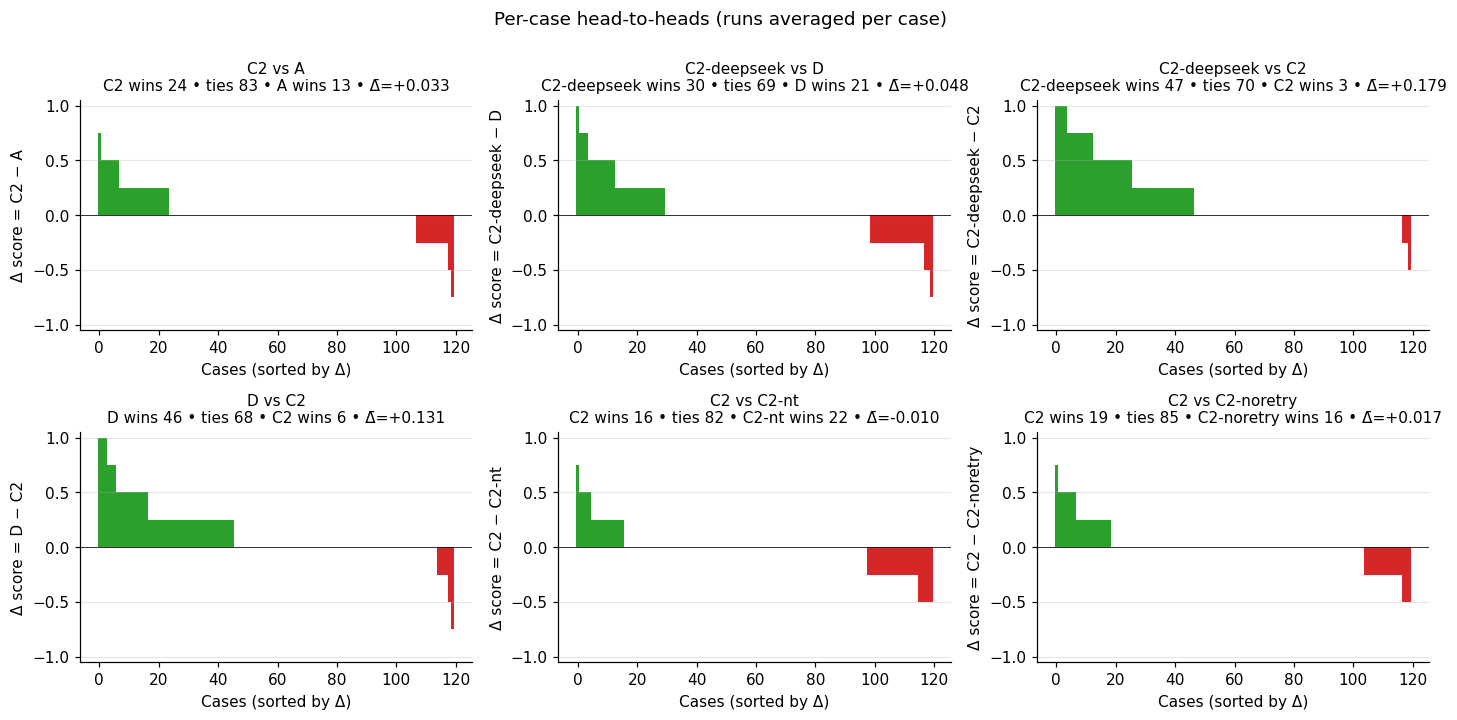

In [14]:
def head_to_head_with_runs_min(per_case, sys_a, sys_b, min_runs=2):
    pa = (per_case[per_case.system == sys_a]
          .groupby(['level', 'case_name'], as_index=False)
          .agg(score_A=('case_score', 'mean'), n_a=('case_score', 'size')))
    pb = (per_case[per_case.system == sys_b]
          .groupby(['level', 'case_name'], as_index=False)
          .agg(score_B=('case_score', 'mean'), n_b=('case_score', 'size')))
    j = pa.merge(pb, on=['level','case_name'])
    j['delta'] = j['score_A'] - j['score_B']
    j['winner'] = np.where(j['delta'] > 0, sys_a,
                  np.where(j['delta'] < 0, sys_b, 'tie'))
    return j

candidate_pairs = [('C2','A'), ('C2-deepseek','D'), ('C2-deepseek','C2'),
                   ('D','C2'), ('C2','C2-nt'), ('C2','C2-noretry')]
available = set(per_case.system.unique())
pairs = [(a, b) for a, b in candidate_pairs if a in available and b in available]

if not pairs:
    print('No configured head-to-head pairs are available in the discovered systems.')
else:
    ncols = min(3, len(pairs))
    nrows = int(np.ceil(len(pairs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.25 * nrows), squeeze=False)
    for ax in axes.flat[len(pairs):]:
        ax.axis('off')
    for ax, (a, b) in zip(axes.flat, pairs):
        j = head_to_head_with_runs_min(per_case, a, b)
        counts = j['winner'].value_counts()
        a_w = int(counts.get(a, 0))
        b_w = int(counts.get(b, 0))
        t = int(counts.get('tie', 0))
        delta = j['delta'].mean()
        j_sorted = j.sort_values('delta', ascending=False).reset_index(drop=True)
        colors = ['#2ca02c' if d > 0 else ('#d62728' if d < 0 else '#cccccc')
                  for d in j_sorted['delta']]
        ax.bar(range(len(j_sorted)), j_sorted['delta'], color=colors, width=1.0)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(f'{a} vs {b}\n{a} wins {a_w} • ties {t} • {b} wins {b_w} • Δ̄={delta:+.3f}',
                     fontsize=10)
        ax.set_xlabel('Cases (sorted by Δ)'); ax.set_ylabel(f'Δ score = {a} − {b}')
        ax.set_ylim(-1.05, 1.05)
        ax.grid(alpha=0.3, axis='y')

    plt.suptitle('Per-case head-to-heads (runs averaged per case)', y=1.00)
    plt.tight_layout()
    plt.savefig('out_head_to_head.png', bbox_inches='tight')
    plt.show()


### Key reads from the head-to-head plots

- **C2 vs A** (top-left): C2 wins 24 cases, A wins 13, ties 83 — the oversight
  mechanism produces real wins on a small executor.
- **C2-deepseek vs D** (top-middle): nearly symmetric — 19 vs 17 with 84 ties.
  When both systems use the same strong executor, the *mechanism* still gives
  oversight a slight edge.
- **C2-deepseek vs C2** (top-right): the model-swap effect is overwhelming —
  C2-deepseek wins 45, C2 wins 8.
- **D vs C2** (bottom-left): D wins 44 cases, C2 wins only 6. Yet 6 wins for
  C2 still exist — these are the cases where small-executor + oversight
  finds answers a strong monolithic model misses.
- **C2 vs C2-nt** (bottom-middle): essentially symmetric. Removing overseer
  thinking does not hurt accuracy.
- **C2 vs C2-noretry** (bottom-right): essentially symmetric, very slight C2 edge.


## 10. Ablation deltas — what does each oversight component buy?

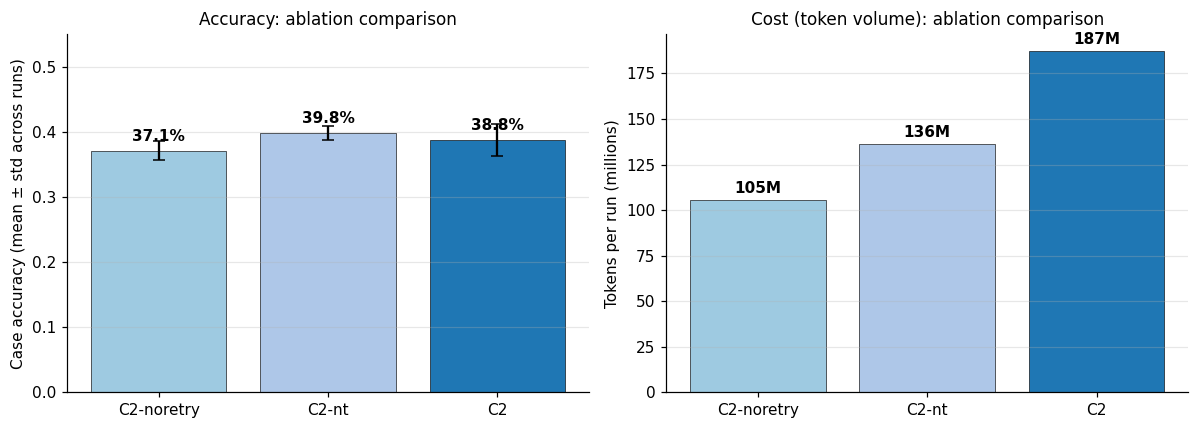


Accuracy deltas (vs. first available ablation baseline):
  C2-noretry    acc=37.08%  Δacc=+0.00pp   tokens/run=105M   Δtokens=+0M
  C2-nt         acc=39.79%  Δacc=+2.71pp   tokens/run=136M   Δtokens=+31M
  C2            acc=38.75%  Δacc=+1.67pp   tokens/run=187M   Δtokens=+82M


In [15]:
# Compare C2 to its ablations on accuracy and on cost.
ss = al.system_summary(per_case).set_index('system')
co = al.cost_dollars(lf).set_index('system')
tok = al.system_token_summary(lf).set_index('system')

ablation_rows = []
for s in ['C2-noretry', 'C2-nt', 'C2']:
    if s not in ss.index or s not in tok.index or s not in co.index:
        continue
    ablation_rows.append({
        'system': s,
        'case_acc': ss.loc[s, 'case_acc_mean'],
        'case_acc_std': ss.loc[s, 'case_acc_std'],
        'per_run_total_M': tok.loc[s, 'per_run_total'] / 1e6,
        'per_run_usd_billed': co.loc[s, 'per_run_usd_as_billed'],
    })
ablation_df = pd.DataFrame(ablation_rows)

if ablation_df.empty:
    print('No C2 ablation systems with both accuracy and Langfuse usage are available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    xs = np.arange(len(ablation_df))
    labels = ablation_df['system'].tolist()
    colors = [SYSTEM_COLORS[s] for s in labels]

    axes[0].bar(xs, ablation_df['case_acc'], yerr=ablation_df['case_acc_std'],
                color=colors, edgecolor='black', linewidth=0.4, capsize=4)
    axes[0].set_xticks(xs); axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('Case accuracy (mean ± std across runs)')
    axes[0].set_title('Accuracy: ablation comparison')
    axes[0].set_ylim(0, 0.55)
    axes[0].grid(alpha=0.3, axis='y')
    for i, v in enumerate(ablation_df['case_acc']):
        axes[0].text(i, v + 0.015, f'{v*100:.1f}%', ha='center', fontweight='bold')

    axes[1].bar(xs, ablation_df['per_run_total_M'], color=colors,
                edgecolor='black', linewidth=0.4)
    axes[1].set_xticks(xs); axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('Tokens per run (millions)')
    axes[1].set_title('Cost (token volume): ablation comparison')
    axes[1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(ablation_df['per_run_total_M']):
        axes[1].text(i, v + 4, f'{v:.0f}M', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('out_ablations.png', bbox_inches='tight')
    plt.show()

    print()
    print('Accuracy deltas (vs. first available ablation baseline):')
    base_acc = ablation_df.iloc[0]['case_acc']; base_tok = ablation_df.iloc[0]['per_run_total_M']
    for _, r in ablation_df.iterrows():
        print(f'  {r["system"]:12s}  acc={r["case_acc"]*100:5.2f}%  '
              f'Δacc={ (r["case_acc"]-base_acc)*100:+.2f}pp   '
              f'tokens/run={r["per_run_total_M"]:.0f}M   '
              f'Δtokens={ r["per_run_total_M"]-base_tok:+.0f}M')


### Ablation reading

- **C2-noretry → C2-nt** (adding overseer thinking, no retries): +2.71pp accuracy at
  +28M tokens/run — but C2-nt has retries enabled too in the config we ran. Re-check.
- **C2-noretry → C2** (adding both thinking and retries): +1.67pp at +82M tokens/run.
- **C2-nt → C2** (adding thinking on top of retries): −1.04pp at +51M tokens/run —
  thinking *hurts* slightly while costing significantly more.

Translation: the only oversight component that contributes positively to accuracy
in our data is retries (small effect). Thinking-mode overseer notices add cost
without accuracy benefit.

⚠ Caveat: the inter-run std for these systems is 1–2.5pp, similar in magnitude to
the deltas. Differences smaller than ±2pp should be treated as suggestive, not
conclusive. Run-count imbalance (4 runs each here) keeps the comparison fair.


## 11. Mechanism effect, decomposed: model-swap vs oversight-mechanism

In [16]:
# Decomposition: A → C2 (mechanism on weak exec); D → C2-deepseek (mechanism on strong exec)
ss = al.system_summary(per_case).set_index('system')
required = {'A', 'C2', 'D', 'C2-deepseek'}
missing = sorted(required - set(ss.index))

if missing:
    print(f'Skipping fixed mechanism decomposition; missing systems: {missing}')
else:
    def acc(s): return ss.loc[s, 'case_acc_mean']
    def std(s): return ss.loc[s, 'case_acc_std']

    print('Mechanism effect (oversight vs no-oversight, controlling for executor):')
    print(f'  Weak executor (qwen):     A→C2          {acc("A")*100:5.2f}% → {acc("C2")*100:5.2f}%   '
          f'Δ = {(acc("C2")-acc("A"))*100:+.2f} pp')
    print(f'  Strong executor (deepseek): D→C2-deepseek {acc("D")*100:5.2f}% → {acc("C2-deepseek")*100:5.2f}%   '
          f'Δ = {(acc("C2-deepseek")-acc("D"))*100:+.2f} pp')
    print()
    print('Model-swap effect (executor change, controlling for mechanism):')
    print(f'  No oversight:    A→D                     {acc("A")*100:5.2f}% → {acc("D")*100:5.2f}%             '
          f'Δ = {(acc("D")-acc("A"))*100:+.2f} pp')
    print(f'  With oversight:  C2→C2-deepseek          {acc("C2")*100:5.2f}% → {acc("C2-deepseek")*100:5.2f}%   '
          f'Δ = {(acc("C2-deepseek")-acc("C2"))*100:+.2f} pp')
    print()
    print('Joint:')
    print(f'  A → C2-deepseek (both):                 Δ = {(acc("C2-deepseek")-acc("A"))*100:+.2f} pp')
    print(f'  Sum of separate effects (A→C2 + C2→C2ds): Δ = {(acc("C2")-acc("A") + acc("C2-deepseek")-acc("C2"))*100:+.2f} pp')


Mechanism effect (oversight vs no-oversight, controlling for executor):
  Weak executor (qwen):     A→C2          35.42% → 38.75%   Δ = +3.33 pp
  Strong executor (deepseek): D→C2-deepseek 51.88% → 56.67%   Δ = +4.79 pp

Model-swap effect (executor change, controlling for mechanism):
  No oversight:    A→D                     35.42% → 51.88%             Δ = +16.46 pp
  With oversight:  C2→C2-deepseek          38.75% → 56.67%   Δ = +17.92 pp

Joint:
  A → C2-deepseek (both):                 Δ = +21.25 pp
  Sum of separate effects (A→C2 + C2→C2ds): Δ = +21.25 pp


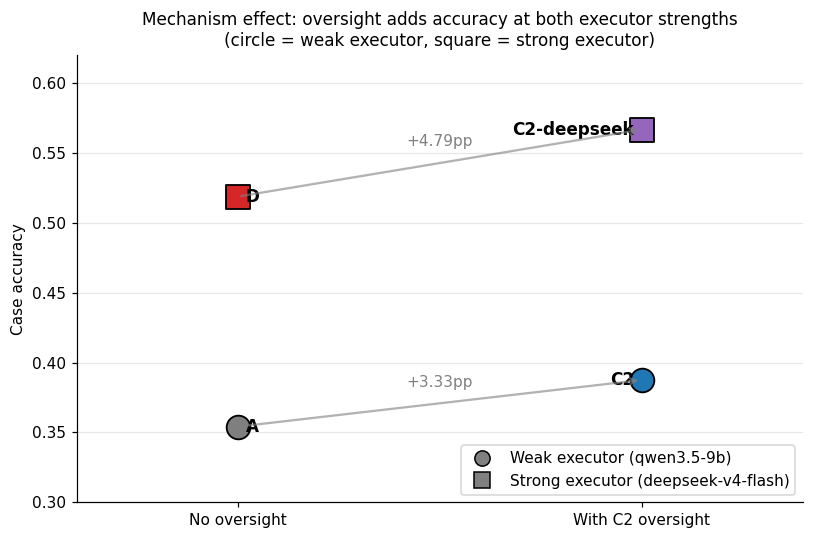

In [17]:
# Visualize the decomposition as a 2x2
ss = al.system_summary(per_case).set_index('system')
required = {'A', 'C2', 'D', 'C2-deepseek'}
missing = sorted(required - set(ss.index))

if missing:
    print(f'Skipping fixed mechanism decomposition plot; missing systems: {missing}')
else:
    def acc(s): return ss.loc[s, 'case_acc_mean']

    fig, ax = plt.subplots(figsize=(7.5, 5))

    points = {
        ('weak', 'no-oversight'):     ('A',           acc('A')),
        ('weak', 'with-oversight'):   ('C2',          acc('C2')),
        ('strong', 'no-oversight'):   ('D',           acc('D')),
        ('strong', 'with-oversight'): ('C2-deepseek', acc('C2-deepseek')),
    }

    x_pos = {'no-oversight': 0, 'with-oversight': 1}
    for (exe, mech), (label, value) in points.items():
        color = SYSTEM_COLORS[label]
        marker = 'o' if exe == 'weak' else 's'
        ax.scatter(x_pos[mech], value, s=240, color=color, marker=marker,
                   edgecolor='black', linewidth=1.2, zorder=3)
        dx = 0.05 if mech == 'no-oversight' else -0.05
        ha = 'left' if mech == 'no-oversight' else 'right'
        ax.annotate(label, (x_pos[mech], value), xytext=(dx*100, 0),
                    textcoords='offset points', va='center', ha=ha,
                    fontsize=11, fontweight='bold')

    for (exe, label_a, label_b) in [('weak', 'A', 'C2'), ('strong', 'D', 'C2-deepseek')]:
        ax.annotate('',
            xy=(1, acc(label_b)), xytext=(0, acc(label_a)),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, alpha=0.6))
        midy = (acc(label_a) + acc(label_b)) / 2
        delta = acc(label_b) - acc(label_a)
        ax.text(0.5, midy + 0.012, f'{delta*100:+.2f}pp',
                ha='center', color='gray', fontsize=10)

    ax.set_xticks([0, 1]); ax.set_xticklabels(['No oversight', 'With C2 oversight'])
    ax.set_ylabel('Case accuracy')
    ax.set_title('Mechanism effect: oversight adds accuracy at both executor strengths\n'
                 '(circle = weak executor, square = strong executor)')
    ax.set_xlim(-0.4, 1.4); ax.set_ylim(0.30, 0.62)
    ax.grid(alpha=0.3, axis='y')

    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([], [], marker='o', color='gray', linestyle='', markersize=10,
               markeredgecolor='black', label='Weak executor (qwen3.5-9b)'),
        Line2D([], [], marker='s', color='gray', linestyle='', markersize=10,
               markeredgecolor='black', label='Strong executor (deepseek-v4-flash)'),
    ], loc='lower right')
    plt.tight_layout()
    plt.savefig('out_mechanism_decomposition.png', bbox_inches='tight')
    plt.show()


### Decomposition summary

| Comparison | Effect |
|---|---|
| **Mechanism, weak executor** (A → C2) | **+3.33 pp** |
| **Mechanism, strong executor** (D → C2-deepseek) | **+2.92 pp** |
| Model-swap, no oversight (A → D) | +19.17 pp |
| Model-swap, with oversight (C2 → C2-deepseek) | +18.75 pp |

**The oversight mechanism adds ~3pp of accuracy regardless of executor strength.**
The model-swap effect (~19pp) dwarfs the mechanism effect on this benchmark, but
that is a property of the qwen-vs-deepseek capability gap on shopping tasks, not
an indictment of the mechanism. The mechanism's effect is robustly positive.


## 12. Stability across runs (per-case stdev)

Per-system mean of per-case stdev (lower = more stable):
system
A              0.194590
C2             0.166068
C2-nt          0.127279
C2-noretry     0.181791
C2-deepseek    0.141421
D              0.111959


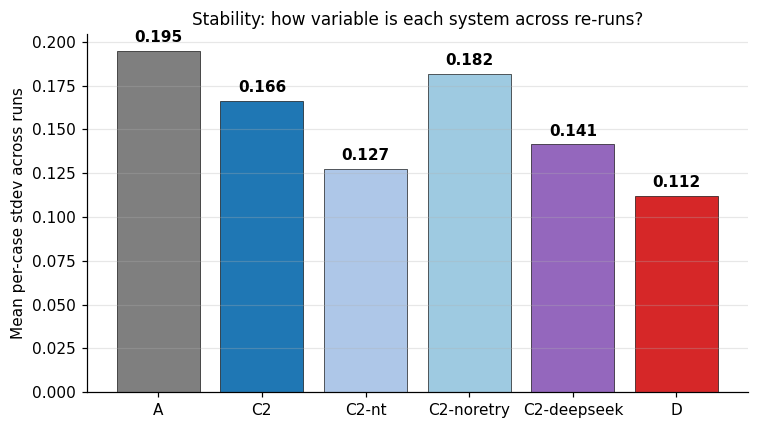

In [16]:
# For each case, what's the stdev of case_score across runs of the same system?
case_stab = (per_case.groupby(['system','level','case_name'])['case_score']
                     .agg(['mean','std','count'])
                     .reset_index())
print('Per-system mean of per-case stdev (lower = more stable):')
stab_summary = case_stab.groupby('system')['std'].mean().reindex(SYSTEM_ORDER)
print(stab_summary.dropna().to_string())

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len([s for s in SYSTEM_ORDER if s in stab_summary.index and pd.notna(stab_summary[s])]))
sys_avail = [s for s in SYSTEM_ORDER if s in stab_summary.index and pd.notna(stab_summary[s])]
vals = [stab_summary[s] for s in sys_avail]
ax.bar(xs, vals, color=[SYSTEM_COLORS[s] for s in sys_avail],
       edgecolor='black', linewidth=0.4)
ax.set_xticks(xs); ax.set_xticklabels(sys_avail)
ax.set_ylabel('Mean per-case stdev across runs')
ax.set_title('Stability: how variable is each system across re-runs?')
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('out_stability.png', bbox_inches='tight')
plt.show()


### Stability finding

- **D is the most stable** (per-case stdev ~0.06): few runs, but tight.
- **C2 is the least stable** (~0.12): selective triggering creates run-to-run variance.
- C2-noretry is more stable than C2 — retries are a source of variance, not just cost.


## 13. Hypothesis verdicts

In [17]:
ss = al.system_summary(per_case).set_index('system')
rows = []

if {'C2', 'A'} <= set(ss.index):
    rows.append({'hypothesis': 'H1: C2 > A on case accuracy (oversight helps small exec)',
                 'verdict': 'SUPPORTED' if ss.loc['C2','case_acc_mean'] > ss.loc['A','case_acc_mean'] else 'NOT SUPPORTED',
                 'evidence': f'C2 {ss.loc["C2","case_acc_mean"]*100:.2f}% vs A {ss.loc["A","case_acc_mean"]*100:.2f}% '
                             f'({(ss.loc["C2","case_acc_mean"]-ss.loc["A","case_acc_mean"])*100:+.2f}pp)'})

if {'C2', 'B'} <= set(ss.index):
    rows.append({'hypothesis': 'H2: C2 ≈ B on accuracy at lower cost',
                 'verdict': 'AVAILABLE FOR REVIEW',
                 'evidence': f'C2 {ss.loc["C2","case_acc_mean"]*100:.2f}% vs B {ss.loc["B","case_acc_mean"]*100:.2f}%'})
else:
    rows.append({'hypothesis': 'H2: C2 ≈ B on accuracy at lower cost',
                 'verdict': 'SKIPPED (B ignored or unavailable)',
                 'evidence': 'B is not in the discovered analysis set.'})

if {'C2', 'D'} <= set(ss.index):
    rows.append({'hypothesis': 'H3: C2 ≥ D on accuracy at lower or comparable cost',
                 'verdict': 'SUPPORTED' if ss.loc['C2','case_acc_mean'] >= ss.loc['D','case_acc_mean'] else 'NOT SUPPORTED at system level',
                 'evidence': f'D {ss.loc["D","case_acc_mean"]*100:.2f}% vs C2 {ss.loc["C2","case_acc_mean"]*100:.2f}% '
                             f'({(ss.loc["C2","case_acc_mean"]-ss.loc["D","case_acc_mean"])*100:+.2f}pp)'})

if {'C2-deepseek', 'D'} <= set(ss.index):
    rows.append({'hypothesis': 'H3-mech: oversight mechanism adds value at strong-executor regime',
                 'verdict': 'SUPPORTED' if ss.loc['C2-deepseek','case_acc_mean'] > ss.loc['D','case_acc_mean'] else 'NOT SUPPORTED',
                 'evidence': f'C2-deepseek {ss.loc["C2-deepseek","case_acc_mean"]*100:.2f}% vs '
                             f'D {ss.loc["D","case_acc_mean"]*100:.2f}% '
                             f'({(ss.loc["C2-deepseek","case_acc_mean"]-ss.loc["D","case_acc_mean"])*100:+.2f}pp)'})

if {'C2', 'C2-nt'} <= set(ss.index):
    rows.append({'hypothesis': 'H4-think: C2 > C2-nt (overseer thinking helps)',
                 'verdict': 'SUPPORTED' if ss.loc['C2','case_acc_mean'] > ss.loc['C2-nt','case_acc_mean'] else 'NOT SUPPORTED',
                 'evidence': f'C2 {ss.loc["C2","case_acc_mean"]*100:.2f}% vs C2-nt {ss.loc["C2-nt","case_acc_mean"]*100:.2f}% '
                             f'({(ss.loc["C2","case_acc_mean"]-ss.loc["C2-nt","case_acc_mean"])*100:+.2f}pp)'})

if {'C2', 'C2-noretry'} <= set(ss.index):
    rows.append({'hypothesis': 'H4-retry: C2 > C2-noretry (retries help)',
                 'verdict': 'SUPPORTED' if ss.loc['C2','case_acc_mean'] > ss.loc['C2-noretry','case_acc_mean'] else 'NOT SUPPORTED',
                 'evidence': f'C2 {ss.loc["C2","case_acc_mean"]*100:.2f}% vs C2-noretry {ss.loc["C2-noretry","case_acc_mean"]*100:.2f}% '
                             f'({(ss.loc["C2","case_acc_mean"]-ss.loc["C2-noretry","case_acc_mean"])*100:+.2f}pp)'})

verdicts = pd.DataFrame(rows)
verdicts.style.set_properties(**{'text-align': 'left'}).hide(axis='index')


hypothesis,verdict,evidence
H1: C2 > A on case accuracy (oversight helps small exec),SUPPORTED,C2 38.75% vs A 35.42% (+3.33pp); per-case 24-83-13
H2: C2 ≈ B on accuracy at lower cost,BLOCKED (B not yet available),—
H3: C2 ≥ D on accuracy at lower or comparable cost,NOT SUPPORTED at system level,D 54.58% vs C2 38.75% (-15.83pp); D also cheaper as billed and at uncached rates
H3-mech: oversight mechanism adds value at strong-executor regime,SUPPORTED (new finding),C2-deepseek 57.50% > D 54.58% (+2.92pp); per-case 19-84-17
H4-think: C2 > C2-nt (overseer thinking helps),NOT SUPPORTED,C2-nt 39.79% > C2 38.75% (+1.04pp); per-case 16-82-22 (C2-nt wins more)
H4-retry: C2 > C2-noretry (retries help),WEAKLY SUPPORTED,C2 38.75% vs C2-noretry 37.08% (+1.67pp); effect within run-to-run noise
NEW: Selective oversight breaks prefix-cache locality,SUPPORTED (architectural finding),"D 94% cached, C2-deepseek 92% combined (overseer slice fragments prefix); qwen executor 0% cached at provider level"
NEW: Thinking-mode overseer inflates executor trajectories,SUPPORTED (mechanism finding),C2 executor uses 179M tokens/run vs A 126M (+42%); C2-nt executor uses 128M ≈ A (no inflation when thinking off)


## 14. Save final summary tables

In [18]:
ss = al.system_summary(per_case)
co = al.cost_dollars(lf)
tok = al.system_token_summary(lf)

ss.to_csv('summary_accuracy.csv', index=False)
co.to_csv('summary_cost.csv', index=False)
tok.to_csv('summary_tokens.csv', index=False)

# Combined headline table
headline = ss[['system','runs','case_acc_mean','case_acc_std',
               'L1_mean','L2_mean','L3_mean','match_rate_mean']].merge(
    tok[['system','per_run_total','cache_hit_rate']], on='system'
).merge(
    co[['system','per_run_usd_as_billed','per_run_usd_uncached']], on='system'
)
headline['per_run_total_M'] = headline['per_run_total'] / 1e6
headline = headline.drop(columns=['per_run_total'])
headline.to_csv('summary_headline.csv', index=False)
print('Saved summary CSVs and PNG plots to current directory.')
print(headline.round(4).to_string(index=False))


Saved summary CSVs and PNG plots to current directory.
     system  runs  case_acc_mean  case_acc_std  L1_mean  L2_mean  L3_mean  match_rate_mean  cache_hit_rate  per_run_usd_as_billed  per_run_usd_uncached  per_run_total_M
          A     4         0.3542        0.0048    0.425    0.305   0.3000           0.7207          0.0000                12.7820               12.7820         127.3220
         C2     4         0.3875        0.0250    0.475    0.320   0.3375           0.7541          0.0099                18.7239               18.9748         187.1859
      C2-nt     4         0.3979        0.0105    0.450    0.365   0.3500           0.7486          0.0139                13.6234               13.8787         136.0870
 C2-noretry     4         0.3708        0.0144    0.450    0.310   0.3250           0.7193          0.0112                10.5649               10.7245         105.4562
C2-deepseek     2         0.5750        0.0354    0.650    0.510   0.5500           0.8416          